# $\color{gray}{\text{7.0 Lecture Note Preparation}}$

```bash
conda create -n net-model python=3.10 -y
conda activate net-model
conda install numpy matplotlib scipy ipykernel ipywidgets jupyter -y
jupyter notebook --no-browser --port=8888
```

- 在[浏览器](http://127.0.0.1:8888)阅读(推荐!)
- [点击](http://127.0.0.1:8888) 并在右上角点击选择 `Trusted`, 并启用插件 `Jupyter Notebook Renderers`, 从而在 VS Code 阅读

# $\color{gray}{\text{7.1 Introduction}}$

## 7.1.1 神经网络的计算潜力

- 网络连接的复杂性: 神经回路中存在广泛的突触连接 [Example] 哺乳动物新皮层(Neocortex) 接收成千上万的突触输入
- 核心计算功能:
  - 坐标变换(Coordinate transformation): 视觉引导运动
  - 选择性放大(Selective amplification): 初级视觉皮层中的简单和复杂细胞模型
  - 积分(Integration): 短期记忆模型
  - 降噪(Noise reduction), 输入选择(Input selection), 增益调节(Gain modulation)
  - 联想记忆(Associative memory)

## 7.1.2 新皮质回路, 以及三种核心连接模式

- 皮层柱(Cortical Columns): 新皮层神经元分布在 6 个垂直的层中, 并形成高度耦合的圆柱结构. 

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/00/Cortical_Columns.jpg/1920px-Cortical_Columns.jpg" width="50%">

- 主要的突触连接类型
  - 前馈连接(Feedforward): 将输入信号从较早阶段区域传递到给定的后续区域
  - 循环连接(Recurrent): 同一阶段/区域内的神经元彼此相连 [Example] 皮层柱内部和柱间
  - 自上而下连接(Top-down): 信号从较晚阶段区域反向传回早期区域 

> 相连区域间, 前馈和自上而下的神经纤维数量通常相当, 即使强度不同. 

## 7.1.3 建模选择

- 脉冲模型(Spiking Models): 刻画脉冲活动. 但是一个模型单元不能替代多个真实神经元的同步放电(否则造成不真实的大规模同步)

- 放电率/发放率模型(Firing-Rate Models)
  - 适用场景: 神经元的不相关放电; 忽略精确脉冲模式
  - 局限性: 无法解释脉冲时序(spike timing)和脉冲相关性(spike correlations)


# $\color{gray}{\text{7.2 Firing-Rate Models}}$

## 7.2.1 从 Spikes 到放电率

> 神经元产生的 Spikes 序列表述为 **神经响应函数** (neural response function) $\begin{aligned}\rho(t) = \sum_{i}A_{i}\delta(t-t_{i})\end{aligned}$

- 核心近似: 使用近似量 **放电率** $r(t)$ 取代了以往的 $\rho(t)$. 也可解读为放电的概率密度, 通过对 $\rho(t)$ 进行系综平均(averaging over trials) $\langle\cdot\rangle$ 得到. 

- 合理性证明: 放电率 $r(t)$ 是否可近似真实 spikes 序列 $\rho(t)$ 在网络中的动力学表现. 
  1. 设依赖网络动力学的物理量 $C$, 若对 $\sigma(\rho) = \langle\rho^{2}\rangle-\langle\rho\rangle^{2}$ 不敏感, 则以 $r(t)$ 替代 $\rho(t)$ 合理. 
  2. 在网络中, 神经元的总输入 $h$ 需要被精确描述. 单个突触的输入方差 $\sigma(h)$ 通常很大. 
    - 不相关输入: 将 $N$ 个不相关突触输入 $h_{j}$ 相加, 则 $\langle h\rangle \propto N$, $\sigma(h) \propto \sqrt{N}$. 使用 $r(t)$ 替代 $\rho(t)$ 是合理的. 
    - 相关输入: Firing-Rate 模型不适用. [Example] 突触前神经元同步放电(synchronous firing)
  3. 突触前 spike 序列输入会被神经元动力学低通滤波, 类似于对输入的平滑. 若建模的突触传递较缓慢, 则 $r(t)$ 近似更准确. 



## 7.2.2 建模步骤

1. 神经元接受到的总突触输入 $h$ 如何依赖突触前输入的放电率 $r$. 

2. 突触后神经元放电率 $r$ 如何依赖总突触输入 $h$. 
   - 总突触输入: 所有突触前动作电位引起突触电导变化, 从而在胞体上产生的总电流 $I_{s}$
   - 假设: 除了动作电位期间, 膜电位始终在略低于阈值水平. 则 $I_{s}$ 接近于胞体测得的突触电流

- $u$: 突触前放电率
- $v$: 突触后放电率

> 考虑多个神经元输入或输出时, 使用矢量形式 $\vec{u}$ 和 $\vec{v}$. 


## 7.2.3 总突触电流(Total Synaptic Current)

<img src=https://files.seeusercontent.com/2026/04/29/uUh8/20260429161426530.png width="50%">

一个神经元接受 $N_{u}$ 个突触 (编号为 $b = \{1,2,\cdots,N_{u}\}$) 输入, 各输入放电率为 $u_{b}$, 或写作 $N_{u}$ 维矢量 $\vec{u}$ 形式. 

$t=0$ 时, $b$ 突触有动作电位, 则 $t = t^{\prime}$ 时该 突触前事件 在 突触后胞体 产生的电流为 $w_{b}K_{s}(t^{\prime})$. 

> - $w_{b}$: $b$ 突触的权重. 
>   - 省去 $b$ 而写作矢量形式, 权重可写作矢量形式 $\vec{w}$
>   - 兴奋性突触 $w_{b} > 0$, 抑制性突触 $w_{b} < 0$
>   - 可令 $w_{b}$ 为变量
> - $K_{s}$: 突触核(synaptic kernel). 

假设单个突触上各 spike 效应独立(线性叠加). 在 $t_{i}$ 时刻 $b$ 突触接收到动作电位, 则 $t$ 时刻的 $b$ 突触的总电流可写作

$$
w_{b}\sum_{t_{i}<t} K_{s}(t - t_{i}) = w_{b} \int_{-\infty}^{t}\mathrm{d}t^{\prime} K_{s}(t-t^{\prime})\rho_{b}(t^{\prime})
$$

> $\begin{aligned}\rho_{b}(t^{\prime}) = \sum_{i} \delta(t^{\prime} - t_{i})\end{aligned}$: 神经响应方程, 表示 $b$ 突触的 spike 序列. 

若突触电流彼此独立, 则所有突触前电流为对 $b$ 求和, 且做替换 $\rho_{b} \to u_{b}$: 

$$
\begin{aligned}
I_{s} &= \sum_{b=1}^{N_{u}} w_{b} \int_{-\infty}^{t}\mathrm{d}t^{\prime}K_{s}(t-t^{\prime})\rho_{b}(t^{\prime})\\
&= \sum_{b=1}^{N_{u}} w_{b} \int_{-\infty}^{t}\mathrm{d}t^{\prime}K_{s}(t-t^{\prime})u_{b}(t^{\prime})
\end{aligned}
$$

突触核 $K_{s}$ 通常选作 $\begin{aligned}\frac{1}{\tau_{r}}e^{-t/\tau_{r}}\end{aligned}$, 对上式 $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}\end{aligned}$ 得到

$$
\begin{aligned}
I_{s} &= \frac{1}{\tau_{s}}e^{-\frac{t}{\tau_{s}}}\sum_{b=1}^{N_{u}}w_{b}\int_{-\infty}^{t}\frac{1}{\tau_{s}} e^{\frac{t^{\prime}}{\tau_{s}}}u_{b}(t^{\prime})\mathrm{d}t^{\prime}\\
\frac{\mathrm{d}I_{s}}{\mathrm{d}t} &= \left[-\frac{1}{\tau_{s}}\left(\frac{1}{\tau_{s}}e^{-\frac{t}{\tau_{s}}}\right)\right]\cdot \left[\sum_{b=1}^{N_{u}}w_{b}\int_{-\infty}^{t}\frac{1}{\tau_{s}} e^{\frac{t^{\prime}}{\tau_{s}}}u_{b}(t^{\prime})\mathrm{d}t^{\prime}\right] + \left[\frac{1}{\tau_{s}}e^{-\frac{t}{\tau_{s}}}\right]\cdot \left[\sum_{b=1}^{N_{u}}w_{b}e^{\frac{t}{\tau_{s}}}u_{b}(t)\right]\\
&= -\frac{1}{\tau_{s}}I_{s} + \frac{1}{\tau_{s}}\sum_{b=1}^{N_{u}}w_{b}u_{b}(t)\\
\Rightarrow \tau_{s}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} &= -I_{s} + \sum_{b=1}^{N_{u}}w_{b}u_{b}(t) = - I_{s} + \vec{w}\cdot\vec{u}(t)
\end{aligned}
$$

> 对于电紧致(electronically compact)树突, $\tau_{s}$ 将接近描述突触电导衰减的时间常数. 

## 7.2.4 The Firing Rate

> 突触后神经元的放电率 $v$ 如何依赖于总突触前输入 $I_{s}$? 

- 稳态: $v = F(I_{s})$
  - $F(\cdot)$ 是稳态放电率函数(steady-state firing rate function)/激活函数. 

  - $F(\cdot)$ 常被取为饱和函数

    - sigmoid 函数 $\begin{aligned}\sigma(x) = \frac{1}{1+e^{-x}}\end{aligned}$. 具有性质 $\sigma^{\prime} = \sigma(1-\sigma)$. 

        <img src=https://cdn.britannica.com/64/264764-050-A2C174FD/graph-of-a-sigmoid-function.jpg width="40%">

    - 阈值线性函数(threshold linear): $ F(I_{s}) = [I_{s}-\gamma]_{+} = \max{(0, I_{s}-\gamma)}$. $\gamma$ 为阈值. 
  - 稳态输出放电率 $v_{\infty}$. 由于 $\begin{aligned}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} = 0\Rightarrow I_{s} = \vec{w}\cdot\vec{u}\end{aligned}$, 则 $v_{\infty} = F(\vec{w}\cdot\vec{u})$. 
- 时间依赖. 
  - I. 延拓为 $v(t) = F(I_{s}(t))$: 放电率瞬时(instantaneously)跟随 $I_{s}$ 变化. 动力学 $\begin{aligned}\tau_{s}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} = - I_{s} + \vec{w}\cdot\vec{u}(t)\end{aligned}$
  - II. 放电率不随总突触输入瞬时变化. 膜电容和电阻具有时间常数, 相当于对 $I_{s}$ 低通滤波. 则 
    $$
    \tau_{r}\frac{\mathrm{d}v}{\mathrm{d}t} = -v + F(I_{s}(t))
    $$
  - 对于 $\tau_{s}$ (控制 `突触前放电率` $u$ $\to$ `突触电流` $I_{s}$) 和 $\tau_{r}$ (控制 `突触电流` $I_{s}$ $\to$ `突触后放电率` $v$), 通常忽略较快的一个而简化模型. 
    - $\tau_{r}\ll \tau_{s}$: II 退化为 I. 
    - $\tau_{s}\ll \tau_{r}$: $\begin{aligned}\frac{\mathrm{d}I_{s}}{\mathrm{d}t}\end{aligned}$ 迅速为 0. 动力学 $\begin{aligned}\tau_{r} \frac{\mathrm{d}v}{\mathrm{d}t} = -v + F(\vec{w}\cdot\vec{u})\end{aligned}$

## 7.2.5 Firing-Rate Dynamics

<img src="https://files.seeusercontent.com/2026/04/29/w1dO/20260429195749349.png" width="60%">



积分-放电 (integrate-and-fire) 神经元. 输入电流 $I(t) = I_{0} + I_{1}\cos{(\omega t)}$ 下的放电率. $\begin{aligned} f = \frac{\omega}{2\pi} = [1, 50, 100]\mathrm{Hz} \end{aligned}$. 直方图是对 spike 进行 binning 得到的, 实线则是 $v(t) = F(I(t))$. 

结论: 若神经元放电足够快, 则膜电位的低通滤波特性不会影响放电率的动力学. 

正在并行模拟 6 组实验，总计 12000 个 Trial...
由于 dt=0.1ms, n_trials=2000，预计耗时可能在 5-15 秒左右，请稍候...
计算完成，耗时: 11.16 秒。


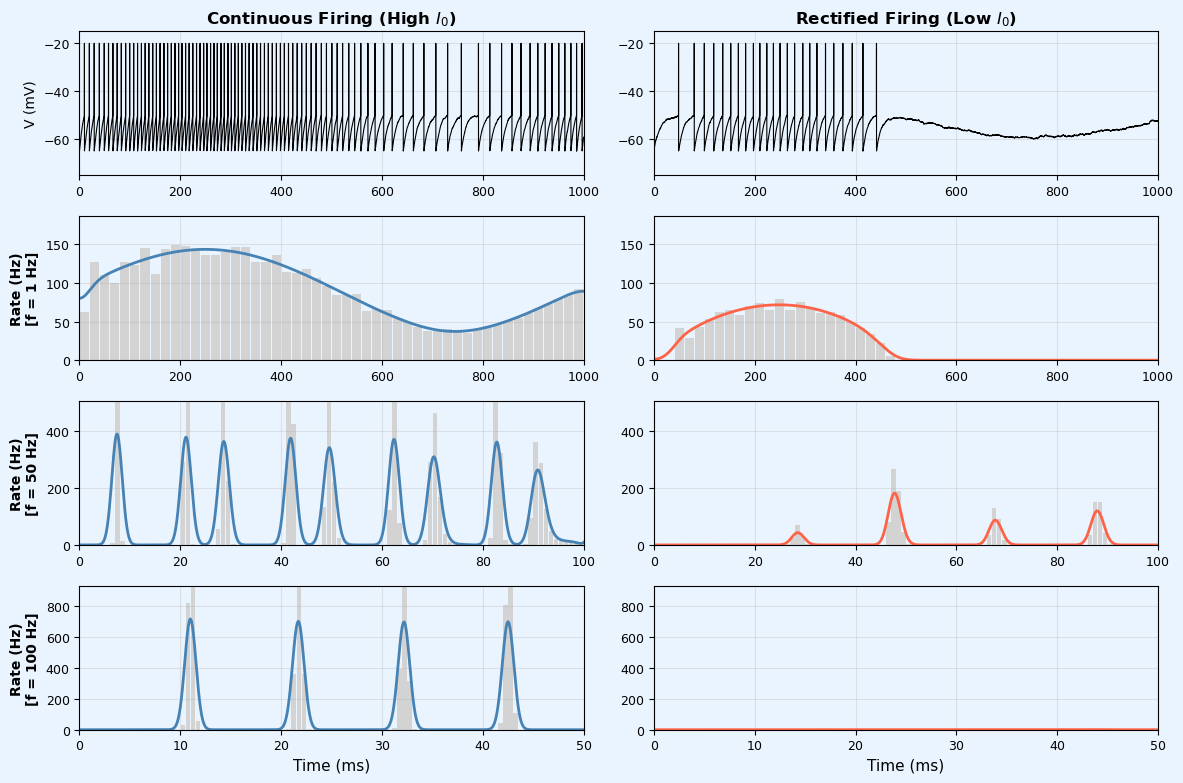

In [12]:
%run tutorials/7.2.py

> 以上的实线是通过高斯模糊得到的, 不是真实的模型预测. 仅供与图 7.2 的对比. 

两种 Firing-Rate 模型都不能在任意 $f$ 和 $I_{0}$ 下准确预测. 需要引入方程 $G(I,v)$ (实线)进行更准确的预测. 

## 7.2.6 Feedforward and Recurrent Networks

<img src="https://files.seeusercontent.com/2026/04/29/Tl3w/20260429213320089.png" width="50%">

- A: 前馈. 输入 $\vec{u}$, 前馈权重 $\mathbb{W}$, 输出 $\vec{v}$
  - 动力学: $\begin{aligned} \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\mathbb{W}\vec{u}) \end{aligned}$, 或分量形式 $\begin{aligned}\tau_{r}\frac{\mathrm{d}v_{i}}{\mathrm{d}t} = -v_{i} + F\left(\sum_{j=1}^{N_{u}}W_{ij}u_{j}\right)\end{aligned}$
- B: 递归. 输入 $\vec{u}$, 前馈权重 $\mathbb{W}$, 递归权重 $\mathbb{M}$, 输出 $\vec{v}$. $M_{ij} = M_{ji}$ 未必成立. 
  - 动力学: $\begin{aligned} \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\mathbb{W}\vec{u} + \mathbb{M}\vec{v}) = -\vec{v} + \vec{F}(\vec{h} + \mathbb{M}\vec{v})\end{aligned}$, 或分量形式 $\begin{aligned}\tau_{r}\frac{\mathrm{d}v_{i}}{\mathrm{d}t} = -v_{i} + F\left(\sum_{j=1}^{N_{u}}W_{ij}u_{j} + \sum_{i^{\prime}=1}^{N_{v}}M_{ii^{\prime}}v_{i^{\prime}}\right)\end{aligned}$
  - Dale's Law: 单个神经元 $i$ 对所有突触 $i^{\prime}$ 要么完全兴奋, 要么完全抑制. 即 $M_{ii^{\prime}}$ 对 $\forall i^{\prime}$ 同号
    - 拆分为兴奋性神经元 (E) 和抑制性神经元 (I), 则
    $$
    \begin{aligned}
    \tau_{E}\frac{\mathrm{d}\vec{v}_{E}}{\mathrm{d}t} &= -\vec{v}_{E} + \vec{F}_{E}(\vec{h}_{E} + \mathbb{M}_{EE}\vec{v}_{E} + \mathbb{M}_{EI}\vec{v}_{I})\\
    \tau_{I}\frac{\mathrm{d}\vec{v}_{I}}{\mathrm{d}t} &= -\vec{v}_{I} + \vec{F}_{I}(\vec{h}_{I} + \mathbb{M}_{IE}\vec{v}_{E} + \mathbb{M}_{II}\vec{v}_{I})
    \end{aligned}
    $$
    - $\mathbb{M}_{EE}$ 和 $\mathbb{M}_{IE}$ 元素 $\geq 0$; $\mathbb{M}_{EI}$ 和 $\mathbb{M}_{II}$ 元素 $\leq 0$.
  - 对称递归矩阵 $M_{ii^{\prime}} = M_{i^{\prime}i}$. 
    - 这违反了 Dale's Law. 兴奋性 $i$ 和抑制性 $i^{\prime}$, 则 $M_{ii^{\prime}} < 0$ 而 $M_{i^{\prime}i} > 0$.
    - 令 $\tau_{I}\to 0$, 则 $\begin{aligned} \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\mathbb{W}\vec{u}) \end{aligned}$ 成为拆分后方程组的一个特例  $\mathbb{M} = \mathbb{M}_{EE} + \mathbb{M}_{EI}\mathbb{M}_{IE}$. 

## 7.2.7 Continuous Labeled Networks

- 离散标记: 相比于 $i,j$, 使用特征参数标记神经元更好. 
  - [Example] 初级视觉皮层: 神经元具有偏好角度(preferred orientation), 则使用 $\theta_{i}$. 
  - 突触前神经元 $i^{\prime}$ 到突触后神经元 $i$ 的权重为 $W_{ii^{\prime}} = W(\theta_{i},\theta_{i^{\prime}})$. 若只依赖角度差: $W_{ii^{\prime}} = W(\theta_{i}-\theta_{i^{\prime}})$
- 连续标记: 大规模网络中, 偏好参数可覆盖连续取值范围. 
  - $\theta\in[0,2\pi]$. 设覆盖密度 $\rho(\theta) = \mathrm{const.}$
  - 放电率和权重为 $\theta$ 函数: $\vec{u}(\theta)$ 和 $\vec{v}(\theta)$; $\mathbb{W}(\theta,\theta^{\prime})$ 和 $\mathbb{M}(\theta,\theta^{\prime})$
  - 动力学: 
  $$
  \begin{aligned}
  \tau_{r} \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} &= -\vec{v} + \vec{F}(\mathbb{W}\vec{u} + \mathbb{M}\vec{v})\\ \Rightarrow
  \tau_{r} \frac{\mathrm{d}\vec{v}(\theta)}{\mathrm{d}t} &= -\vec{v}(\theta) + \vec{F}\left(\rho_{\theta}\int_{-\pi}^{+\pi}\mathrm{d}\theta^{\prime}\left[\mathbb{W}(\theta,\theta^{\prime})\vec{u}(\theta^{\prime}) + \mathbb{M}(\theta,\theta^{\prime})\vec{v}(\theta^{\prime})\right]\right)
  \end{aligned}
  $$

# $\color{gray}{\text{7.3 Feedforward Networks}}$

## 7.3.1 Neural Coordinate Transformations(神经坐标变换)

Reach 任务中的坐标变换: 注视方向不同 $\to$ 同一物体在视网膜上受刺激位置不同
    
- 角度记号

  <img src="https://files.seeusercontent.com/2026/04/30/0gMw/20260430150704898.png" width="50%">

  - $s$: 刺激的视网膜角坐标 (刺激位置 $\vec{S}$ 与注视方向 $\vec{F}$ 夹角)
  - $g$: 眼球的注视角 (注视方向 $\vec{F}$ 与头朝向 $\hat{n}$ 夹角)
  - $s+g$: 目标相对头朝向的偏转角 (目标位置 $\vec{S}$ 与头朝向 $\hat{n}$ 夹角)
- 猴 前运动皮层对视觉刺激有反应的神经元的调制曲线

  <img src="https://files.seeusercontent.com/2026/04/30/Bg0c/20260430153328111.png" width="55%">

  - A: 固定猴头朝向 $\hat{n}$. 控制猴子注视 "+" 标记(三种, 对应不同曲线), 从而固定注视方向 $\vec{F}$. 另一个物体环绕猴子移动 ($s+g\in (-30^{\circ}, 60^{\circ})$). 
    - 注意到对于不同注视方向 $g$, 在 $s+g$ 上的调制曲线几乎不变
    - 结论: 前运动皮层神经元仅依赖于 $s+g$, 即目标相对头朝向的偏转角, 而非视网膜角坐标 $s$. 
  - B: 猴头朝向 $\hat{n}(\theta)$ 和 $\hat{n}(\theta + 15^{\circ})$. 在 $s$ 上调制曲线发生了 $15^{\circ}$ 的平移. 
    - 结论: 前运动皮层的感受野是基于目标相对头朝向的偏转角 $s+g$. 当 $g^{\prime} = g + \delta\theta$, 则 $s^{\prime} = s - \delta\theta$ 维持调制曲线不变. 
  - C: 前馈模型计算得到的调制曲线. $g = [0^{\circ}, 10^{\circ}, -20^{\circ}]$
    - 结论: 前馈模型预测和 B 中的调制曲线偏移现象一致. 
- 神经元模型: 调制曲线为 $s+g$ 的函数
  - 生物学基础: 顶叶后部皮层(posterior parietal cortex) 7a 区同时依赖于 $s$ 和 $g$. 
  - 增益调节(gaze-dependent gain modulation): 注视方向 $g$ 改变的是 7a 的调制曲线的幅值 (不同于前文的偏移机制)

    <img src="https://files.seeusercontent.com/2026/04/30/aGz0/20260430164409174.png" width="60%">
    
    - A: $s$ 为横轴. 两曲线的 $g$ 不同, 仅仅是改变了幅值而没有改变分布. 
    - B: $r(s,g)$ 三维图. 
      - $\xi$: 偏好的视网膜角坐标
      - $\gamma$: 产生最大增益的一般的注视方向
  - 建模
    - 输出: 运动前区皮层神经元
    - 输入: 7a 区神经元群 (增益调节). 放电率调制曲线: $u_{i} = f_{u}(s-\xi_{i}, g-\gamma_{i})$, 是 $(s-\xi_{i})$ 的高斯曲线 $\times$ $(g-\gamma_{i})$ 的 sigmoid 曲线.
    - 稳态响应: 
      - 输入量 $\begin{aligned}h = \vec{w}\cdot\vec{u} = \sum_{i} w_{i}u_{i} = \sum_{i=1}^{N} w_{i}f_{u}(s-\xi_{i}, g-\gamma_{i})\end{aligned}$
      - 稳态响应(离散): $\begin{aligned}v_{\infty} = F(h) = F \left(\sum_{i=1}^{N} w_{i}f_{u}(s-\xi_{i}, g-\gamma_{i})\right)\end{aligned}$
      - 稳态响应(连续): 将配对的 $(\xi_{i},\gamma_{i})$ 拆分为 $(\xi_{j},\gamma_{k})$, 从而应用 $\begin{aligned}\sum_{j}\Delta\xi \to \int\mathrm{d}\xi\end{aligned}$ 和 $\begin{aligned}\sum_{k}\Delta\gamma\to\int\mathrm{d}\gamma\end{aligned}$: $\begin{aligned}v_{\infty} = F\left[\rho_{\xi}\rho_{\gamma}\iint\mathrm{d}\xi\mathrm{d}\gamma\, w(\xi,\gamma)f_{u}(s-\xi, g-\gamma)\right]\end{aligned}$
      - 以身体为中心($s+g$ 函数). 令 $\begin{aligned}\xi\to \xi - g,\,\gamma\to\gamma + g:\,v_{\infty} = F\left[\rho_{\xi}\rho_{\gamma}\iint\mathrm{d}\xi\mathrm{d}\gamma\,w(\xi-g,\gamma+g)f_{u}(s+g-\xi, -\gamma)\right]\end{aligned}$. 且要求 $w(\xi-g,\gamma+g) = w(\xi, \gamma)$. 见 Chapter 8. 
    - 结论: 增益调节神经元通过乘法结合感觉输入 $s$ 和调制输入 $g$. 

*提示: 推荐使用[网页端](http://127.0.0.1:8888)使用以下代码. 若 VS Code 未配置好则会陷入无限卡死!*


In [ ]:
%run tutorials/7.6.py